In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [20]:
# Column names for the dataset
columns = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor_{i}' for i in range(1, 22)]

# Load training data with correct separator
df = pd.read_csv('/Users/adhithya/Desktop/TURBOFAN PROJECT/train_FD001.txt', 
                  sep=r'\s+', header=None, names=columns, engine='python')

print("Data loaded! Shape:", df.shape)
print(df[['engine_id', 'cycle']].head())

Data loaded! Shape: (20631, 26)
   engine_id  cycle
0          1      1
1          1      2
2          1      3
3          1      4
4          1      5


In [21]:
print("Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nBasic statistics:")
df.describe()

Shape: (20631, 26)

First few rows:
   engine_id  cycle     op1     op2    op3  sensor_1  sensor_2  sensor_3  \
0          1      1 -0.0007 -0.0004  100.0    518.67    641.82   1589.70   
1          1      2  0.0019 -0.0003  100.0    518.67    642.15   1591.82   
2          1      3 -0.0043  0.0003  100.0    518.67    642.35   1587.99   
3          1      4  0.0007  0.0000  100.0    518.67    642.35   1582.79   
4          1      5 -0.0019 -0.0002  100.0    518.67    642.37   1582.85   

   sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  sensor_15  \
0   1400.60     14.62  ...     521.66    2388.02    8138.62     8.4195   
1   1403.14     14.62  ...     522.28    2388.07    8131.49     8.4318   
2   1404.20     14.62  ...     522.42    2388.03    8133.23     8.4178   
3   1401.87     14.62  ...     522.86    2388.08    8133.83     8.3682   
4   1406.22     14.62  ...     522.19    2388.04    8133.80     8.4294   

   sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sens

,engine_id,cycle,op1,op2,op3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [22]:
print("Missing values in each column:")
print(df.isnull().sum())
print("\nTotal engines:", df['engine_id'].nunique())
print("Total cycles recorded:", len(df))

Missing values in each column:
engine_id    0
cycle        0
op1          0
op2          0
op3          0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64

Total engines: 100
Total cycles recorded: 20631


In [23]:
# Find the last cycle for each engine (when it failed)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge and calculate RUL
df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']

print("RUL added successfully!")
print(df[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(10))

RUL added successfully!
   engine_id  cycle  max_cycle  RUL
0          1      1        192  191
1          1      2        192  190
2          1      3        192  189
3          1      4        192  188
4          1      5        192  187
5          1      6        192  186
6          1      7        192  185
7          1      8        192  184
8          1      9        192  183
9          1     10        192  182


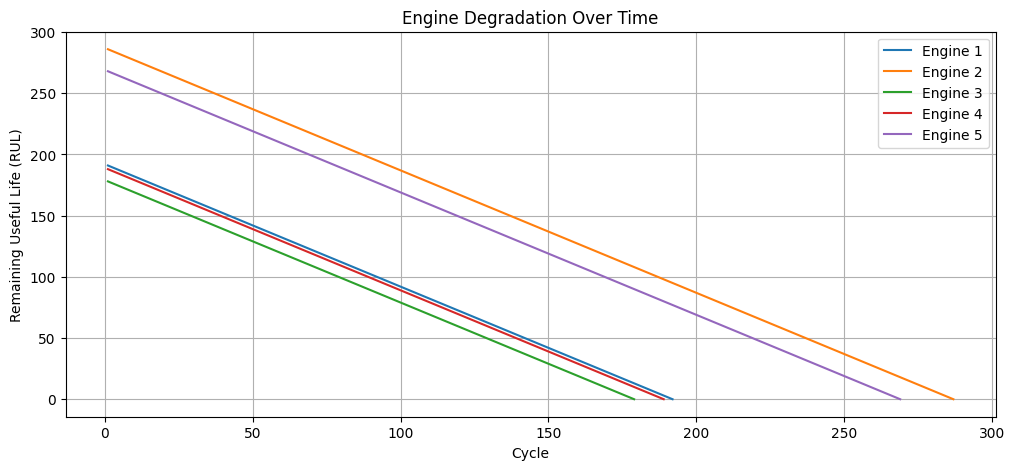

In [24]:
plt.figure(figsize=(12, 5))

# Plot RUL for first 5 engines
for engine in range(1, 6):
    engine_data = df[df['engine_id'] == engine]
    plt.plot(engine_data['cycle'], engine_data['RUL'], label=f'Engine {engine}')

plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life (RUL)')
plt.title('Engine Degradation Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# These sensors don't change much — we'll drop them
drop_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 
                'sensor_16', 'sensor_18', 'sensor_19']

# Features (what the model learns from)
feature_cols = [col for col in df.columns 
                if col not in ['engine_id', 'cycle', 'max_cycle', 'RUL'] 
                and col not in drop_sensors]

X = df[feature_cols]
y = df['RUL']

print("Features used:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features used: ['op1', 'op2', 'op3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
X shape: (20631, 17)
y shape: (20631,)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16504
Testing samples: 4127


In [27]:
from sklearn.ensemble import RandomForestRegressor

# Build the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train it
print("Training model... this may take 1-2 minutes...")
model.fit(X_train, y_train)

print("Model trained successfully!")

Training model... this may take 1-2 minutes...
Model trained successfully!


In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} cycles")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 29.59 cycles
R² Score: 0.6257


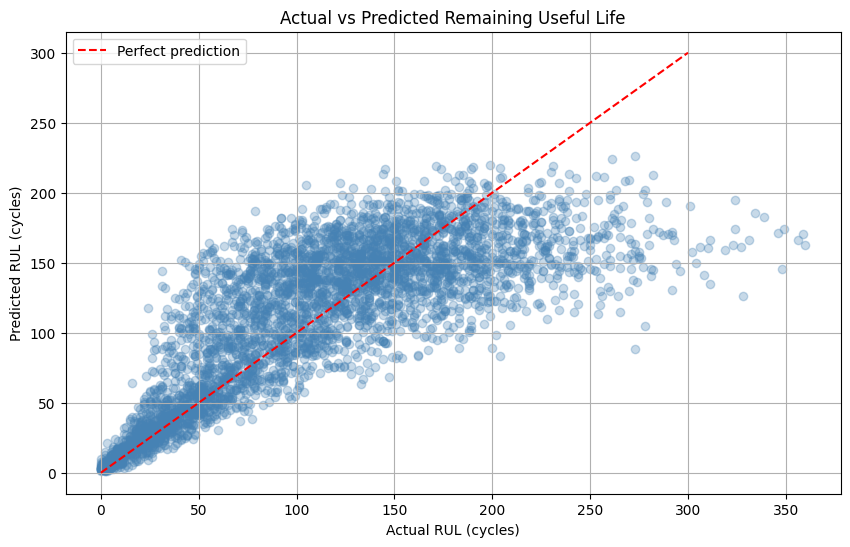

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([0, 300], [0, 300], 'r--', label='Perfect prediction')
plt.xlabel('Actual RUL (cycles)')
plt.ylabel('Predicted RUL (cycles)')
plt.title('Actual vs Predicted Remaining Useful Life')
plt.legend()
plt.grid(True)
plt.show()

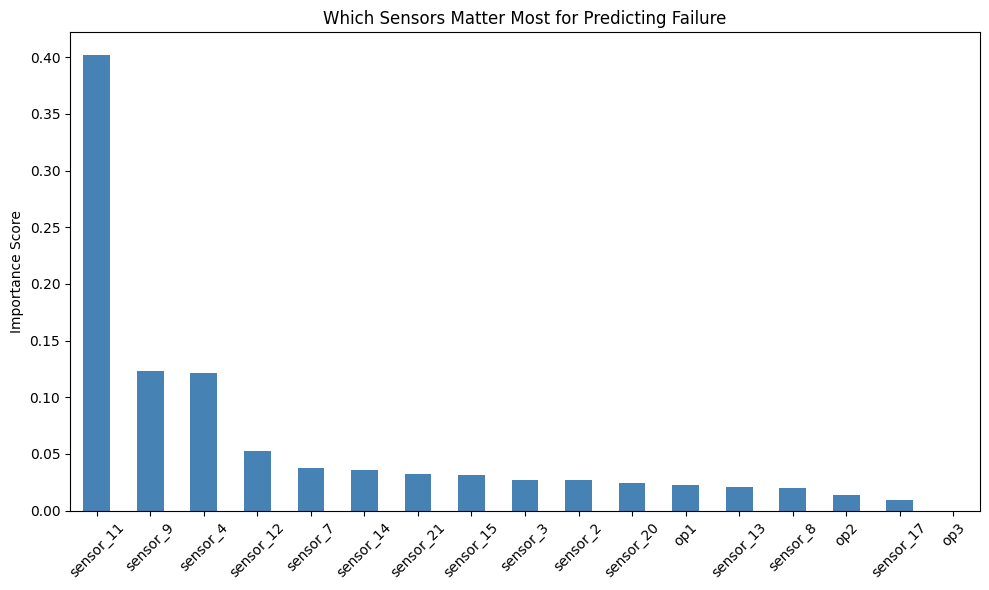

In [30]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='steelblue')
plt.title('Which Sensors Matter Most for Predicting Failure')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()